In [2]:
import pennylane as qp
from pennylane import numpy as np
import matplotlib

qml = qp

C:\Users\julia\AppData\Local\Temp\ipykernel_11452\3529098593.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


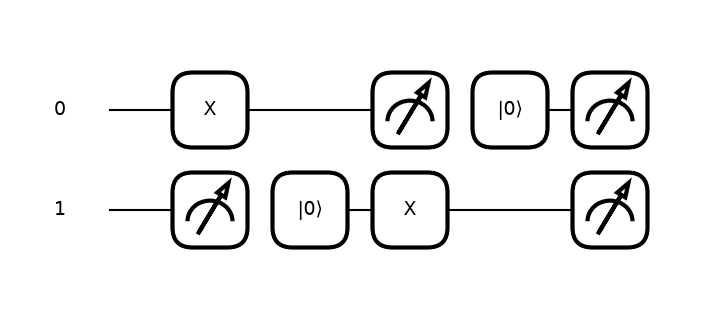

In [4]:
dev = qp.device("default.qubit", wires=2)

@qp.qnode(dev)
def circuit():
    qp.X(wires=0)
    m_1 = qp.measure(0, reset=True)
    m_2 = qp.measure(1, reset=True)
    qp.X(wires=1)
    
    return qp.probs(wires=[0,1])

fig, ax = qp.draw_mpl(circuit)()
fig.show()

In [5]:
dev = qp.device("default.qubit")

@qp.qnode(dev)
def circuit(x):
    qp.RX(x, wires=0)
    m_0 = qp.measure(0, postselect=0)
    return qp.sample(wires=0)

print(circuit(np.pi/2, shots=10))

[[0]
 [0]
 [0]
 [0]]


c:\Users\julia\Documents\estudos\pennylane\code-pennylane\.venv\Lib\site-packages\pennylane\workflow\qnode.py:825: PennyLaneDeprecationWarning: Specifying 'shots' when executing a QNode is deprecated and will be removed in v0.44. Please set shots on QNode initialization, or use qp.set_shots instead.
  shots = self._get_shots(kwargs)


In [8]:
dev = qp.device('default.qubit')

@qp.qnode(dev)
def qnode_conditional_op_on_zero(x, y):
    qp.RY(x, wires=0)
    qp.CNOT(wires=[0, 1])
    m_0 = qp.measure(1)

    qp.cond(m_0 == 0, qp.RY)(y, wires=0)
    return qp.probs(wires=[0])

pars = np.array([0.643, 0.246], requires_grad=True)
qnode_conditional_op_on_zero(*pars)

tensor([0.88660045, 0.11339955], requires_grad=True)

In [10]:
n_shots = 10000
dev = qp.device("default.qubit", shots=n_shots)
np.random.seed(0)

@qp.qnode(dev)
def circuit():
    qp.H(wires=0)
    # 1st beam-splitter
    m_bomb = qp.measure(wires=0, postselect=0)
    qp.H(wires=0)
    # 2nd beam-splitter
    m_det = qp.measure(0)
    qp.cond(m_det == 1, qp.Hadamard)(wires=0)
    m_det_2 = qp.measure(0, postselect=0)
    qp.Hadamard(0)
    m_det_3 = qp.measure(0)
    return qp.counts(op=[m_bomb, m_det]), qp.counts(op=[m_det, m_det_3])

results = circuit()
prob_suc_1 = results[0]["00"] / n_shots
prob_suc_2 = results[1]["10"] / n_shots

prob_suc = prob_suc_1 + prob_suc_2
print('the success probability is', prob_suc)

the success probability is 0.3127
